# Hotel Booking Demand: Full Analysis

**Main question:** why do hotel bookings get cancelled, and what can the hotels do about it?

**Data:** 119,390 bookings from two hotels in Portugal (a City Hotel and a Resort Hotel) for arrivals between July 2015 and August 2017. Each row is one booking.

**How to read this notebook:** every section starts with a short note on *what* we do and *why*. The code is commented so you can follow it line by line. All charts are also saved as PNG files in the `figures/` folder.

**Sections**
1. Load and understand the data
2. Clean the data
3. What drives cancellations?
4. Seasonality (and a common trap)
5. Revenue
6. Are the differences real? (statistical tests)
7. Predicting cancellations (machine learning)
8. Conclusions and recommendations

## Key findings

1. **Cancellations are a big problem.** 37% of bookings are cancelled (44,198 of 119,208). They represent **EUR 16.7M of room value, 39% of everything booked**. The City Hotel is hit harder (42% of bookings cancelled) than the Resort Hotel (28%).
2. **Lead time is the strongest everyday driver.** Bookings made within a week are cancelled 10% of the time. Bookings made over a year ahead are cancelled 68% of the time.
3. **One odd group explains a third of all cancellations.** 14,586 "non-refundable" bookings were cancelled 99% of the time. They don't look like normal travellers: 97% are from Portugal, 63% are group bookings and 98% have identical twin rows. They look like large block reservations made by agencies and released later. They also explain most of Portugal's high cancellation rate.
4. **Committed guests rarely cancel.** Guests with one or more special requests cancel 17-22% of the time, versus 48% with none. Repeat guests cancel 15% (first-time guests 38%), and direct bookings 15% (online travel agents 37%).
5. **"August is the busiest month" is a counting mistake.** July and August appear in 3 years of data and every other month in 2. In the one complete year (2016), the City Hotel is busiest in spring and autumn. The Resort Hotel earns the most in July and August because prices peak (EUR 187 per night in August vs EUR 45 in January) and guests stay longer, not because more guests arrive.
6. **Cancellations can be predicted.** A model using only information known at booking time reaches an AUC of 0.83 on 2017 bookings (0.5 = guessing, 1.0 = perfect). Of the bookings it rates 80-100% risky, 98% really were cancelled.

## 0. Setup

Import the libraries and set one chart style for the whole notebook.

**Colour rule:** one colour means one thing everywhere in this notebook.
- **Blue** = City Hotel, **orange** = Resort Hotel.
- **Purple** = all bookings together (charts with a single series).
- **Grey** = the "before" or comparison value we want you to look past.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, FuncFormatter, MultipleLocator
from scipy import stats

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Colours (one meaning each)
CITY, RESORT = '#2a78d6', '#eb6834'      # the two hotels
HOTEL_COLORS = {'City Hotel': CITY, 'Resort Hotel': RESORT}
MAIN = '#4a3aa7'                          # all bookings / the value that matters
GREY = '#a3a199'                          # comparison / "before" value
INK, INK2, MUTED, GRID = '#0b0b0b', '#52514e', '#898781', '#e1e0d9'

plt.rcParams.update({
    'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb', 'savefig.facecolor': '#fcfcfb',
    'font.family': 'Segoe UI', 'font.size': 10,
    'text.color': INK, 'axes.labelcolor': INK2, 'axes.titlecolor': INK,
    'axes.titlesize': 12, 'axes.titleweight': 'semibold', 'axes.titlelocation': 'left', 'axes.titlepad': 12,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'xtick.labelcolor': INK2, 'ytick.labelcolor': INK2,
    'axes.edgecolor': '#c3c2b7', 'axes.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.6, 'grid.linestyle': '-',
    'axes.axisbelow': True, 'legend.frameon': False,
    'lines.linewidth': 2, 'lines.markersize': 6,
    'figure.dpi': 110, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
})

FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)
pct = PercentFormatter(1, decimals=0)    # shows 0.37 as 37%

MONTHS = ['January', 'February', 'March', 'April', 'May', 'June', 'July',
          'August', 'September', 'October', 'November', 'December']
MONTH_ABBR = [m[:3] for m in MONTHS]


def save(fig, name):
    """Save a chart into figures/ and show it."""
    fig.savefig(FIG_DIR / f'{name}.png')
    plt.show()

## 1. Load and understand the data

Before changing anything, look at what we have: the size, the column types and what is missing.

In [2]:
df = pd.read_csv('data/hotel_bookings.csv')
ORIGINAL_COLUMNS = list(df.columns)
print(f'{df.shape[0]:,} rows (bookings) and {df.shape[1]} columns')
df.head()

119,390 rows (bookings) and 32 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.00,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.00,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.00,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [4]:
# How many values are missing in each column?
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pd.DataFrame({'missing': missing, 'percent': (missing / len(df) * 100).round(1)})

,missing,percent
company,112593,94.30
agent,16340,13.70
country,488,0.40
children,4,0.00


**What the missing values mean**

| Column | Missing | Meaning | What we do |
|---|---|---|---|
| `company` | 94% | Most guests are not sent by a company. Empty means "no company", **not an error**. | Add a yes/no column `has_company` |
| `agent` | 14% | Booked directly, without a travel agent. | Add a yes/no column `has_agent` |
| `country` | 0.4% | Country not recorded. | Label as `Unknown` |
| `children` | 4 rows | Probably 0. | Fill with 0 |

**Lesson:** an empty cell is not always a mistake. Ask what it means before you delete or fill it.

## 2. Clean the data

Every cleaning step is a decision. We write down each one so someone else could repeat it or disagree with it.

In [5]:
start_rows = len(df)

# --- 1. Fill missing values where the meaning is clear ---
df['children'] = df['children'].fillna(0).astype(int)     # 4 rows: assume no children
df['country'] = df['country'].fillna('Unknown')            # keep these bookings, label the country
df['has_agent'] = df['agent'].notna().astype(int)          # 1 = booked through a travel agent
df['has_company'] = df['company'].notna().astype(int)      # 1 = a company booked/paid

# --- 2. Merge labels that mean the same thing ---
df['meal'] = df['meal'].replace('Undefined', 'SC')         # both mean "no meal package"

# --- 3. Remove impossible rows ---
guests = df['adults'] + df['children'] + df['babies']
problems = pd.DataFrame({
    'No guests at all': guests == 0,
    'Negative price (adr < 0)': df['adr'] < 0,
    'Price over 1,000 per night': df['adr'] > 1000,
})
print(problems.sum().to_string(), '\n')
bad = problems.any(axis=1)
df = df[~bad].copy()
print(f'Removed {bad.sum()} rows ({bad.sum() / start_rows:.2%}). {len(df):,} bookings left.')

# --- 4. Add helpful columns ---
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' + df['arrival_date_month'] + '-'
    + df['arrival_date_day_of_month'].astype(str), format='%Y-%B-%d')
df['month_num'] = df['arrival_date'].dt.month
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['booking_value'] = df['adr'] * df['total_nights']       # room revenue IF the guest actually comes

print(f"Arrivals from {df['arrival_date'].min():%d %b %Y} to {df['arrival_date'].max():%d %b %Y}")

No guests at all              180
Negative price (adr < 0)        1
Price over 1,000 per night      1 

Removed 182 rows (0.15%). 119,208 bookings left.


Arrivals from 01 Jul 2015 to 31 Aug 2017


### What about the duplicate rows?

About 32,000 rows are exact copies of another row. Many tutorials delete them straight away. But this dataset has **no booking ID**, so two identical rows could be two real rooms booked together, for example a tour group booking 20 identical double rooms. Let's look at who the duplicates are before deciding.

In [6]:
df['is_duplicate'] = df.duplicated(subset=ORIGINAL_COLUMNS, keep=False)   # True for every copy, including the first
print(f"{df.duplicated(subset=ORIGINAL_COLUMNS).sum():,} rows are copies of an earlier row\n")

def share(d, col, value):
    return d[col].eq(value).mean()

pd.DataFrame({
    'Rows with an identical twin': [share(df[df.is_duplicate], 'market_segment', 'Groups'),
                                    share(df[df.is_duplicate], 'deposit_type', 'Non Refund'),
                                    df.loc[df.is_duplicate, 'is_canceled'].mean()],
    'Unique rows': [share(df[~df.is_duplicate], 'market_segment', 'Groups'),
                    share(df[~df.is_duplicate], 'deposit_type', 'Non Refund'),
                    df.loc[~df.is_duplicate, 'is_canceled'].mean()],
}, index=['Market segment = Groups', 'Deposit = Non Refund', 'Cancelled']).map(lambda v: f'{v:.0%}')

31,980 rows are copies of an earlier row



,Rows with an identical twin,Unique rows
Market segment = Groups,42%,4%
Deposit = Non Refund,36%,0%
Cancelled,58%,26%


**Decision: keep the duplicates.** Rows with an identical twin are mostly group bookings (42% vs 4% for unique rows) and non-refundable deposits (36% vs 0%). That is exactly what a block of identical rooms booked together looks like. Deleting them would treat 30 real rooms as one.

This choice changes some numbers, so in Section 3.6 we check that our conclusions hold either way.

## 3. What drives cancellations?

### 3.1 The headline number

In [7]:
OVERALL = df['is_canceled'].mean()
print(f"{df['is_canceled'].sum():,} of {len(df):,} bookings were cancelled = {OVERALL:.1%}\n")

by_hotel = df.groupby('hotel')['is_canceled'].agg(bookings='size', cancelled='sum', rate='mean')
by_hotel['rate'] = by_hotel['rate'].map('{:.1%}'.format)
by_hotel

44,198 of 119,208 bookings were cancelled = 37.1%



,bookings,cancelled,rate
hotel,,,
City Hotel,79162,33078,41.8%
Resort Hotel,40046,11120,27.8%


A single number does not need a chart. More than **1 in 3 bookings is cancelled**, and the City Hotel is hit much harder than the Resort Hotel.

### 3.2 Lead time: the strongest single driver

*Lead time* = days between making the booking and the arrival date. We group it into ranges and compute the cancellation rate for each range.

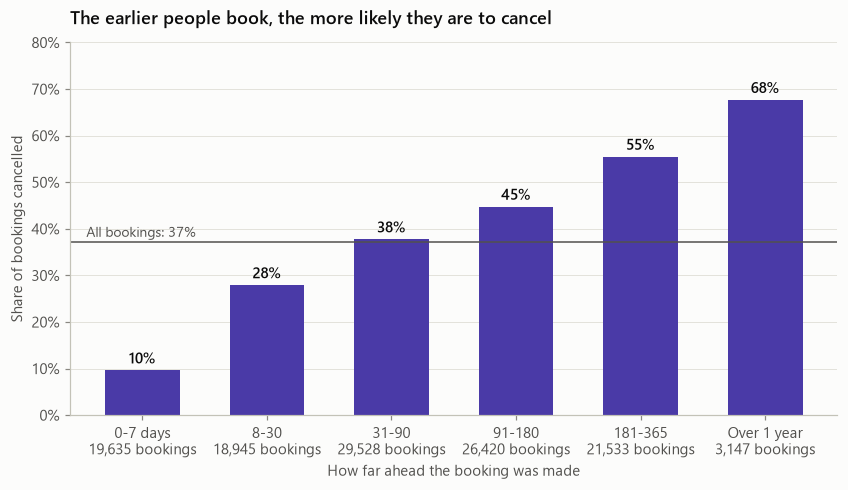

In [8]:
bins = [-1, 7, 30, 90, 180, 365, df['lead_time'].max()]
labels = ['0-7 days', '8-30', '31-90', '91-180', '181-365', 'Over 1 year']
df['lead_time_group'] = pd.cut(df['lead_time'], bins=bins, labels=labels)

lt = df.groupby('lead_time_group', observed=True)['is_canceled'].agg(rate='mean', n='size')

fig, ax = plt.subplots(figsize=(9, 4.4))
x = np.arange(len(lt))
ax.bar(x, lt['rate'], color=MAIN, width=0.6)
for xi, r in zip(x, lt['rate']):
    ax.text(xi, r + 0.015, f'{r:.0%}', ha='center', fontsize=10, fontweight='semibold')
ax.axhline(OVERALL, color=INK2, lw=1)
ax.text(-0.45, OVERALL + 0.012, f'All bookings: {OVERALL:.0%}', ha='left', fontsize=9, color=INK2)
ax.set_xticks(x, [f'{lab}\n{n:,} bookings' for lab, n in zip(lt.index, lt['n'])])
ax.set_ylim(0, 0.8)
ax.yaxis.set_major_formatter(pct)
ax.grid(axis='x', visible=False)
ax.set_xlabel('How far ahead the booking was made')
ax.set_ylabel('Share of bookings cancelled')
ax.set_title('The earlier people book, the more likely they are to cancel')
save(fig, '01_cancellation_by_lead_time')

**What this shows:** the cancellation rate rises steadily with lead time, from **10%** for last-minute bookings to **68%** for bookings made more than a year ahead. The further away the trip, the more time there is for plans to change, and booking early with free cancellation costs the guest nothing.

Bookings made more than 6 months ahead are 21% of all bookings but 32% of all cancellations.

### 3.3 Other factors

Each panel shows the cancellation rate for one booking characteristic. The vertical line is the average for all bookings. The number in brackets is how many bookings each bar is based on. We hide groups with fewer than 100 bookings, because a rate based on 2 bookings tells us nothing.

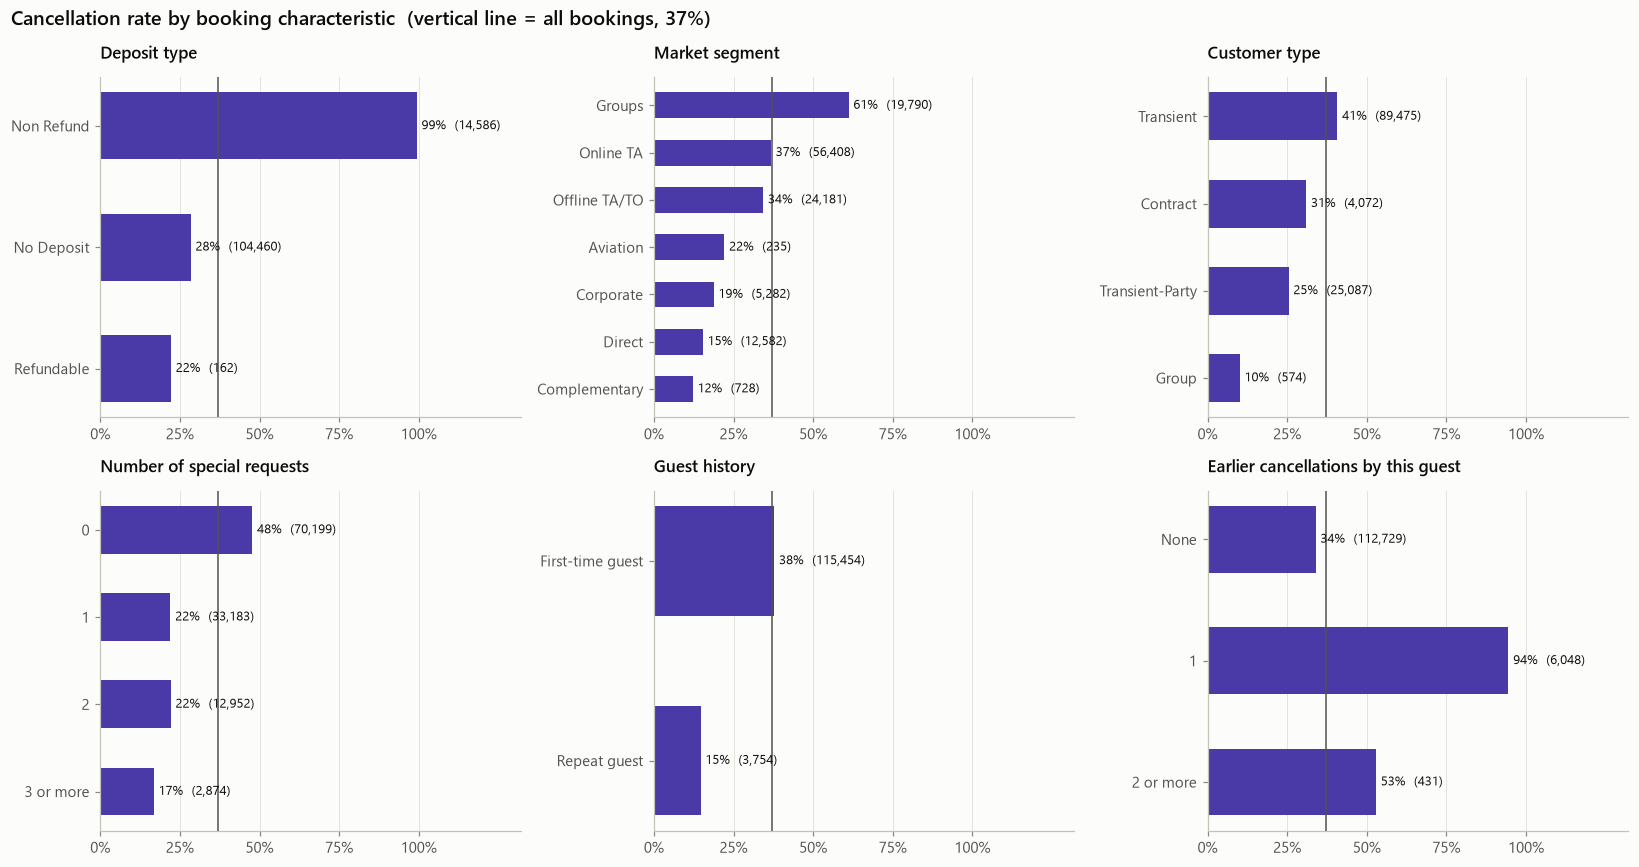

In [9]:
def rate_bars(ax, data, by, title, order=None, min_n=100):
    """Horizontal bars: cancellation rate per group, with the % and the number of bookings."""
    s = data.groupby(by, observed=True)['is_canceled'].agg(rate='mean', n='size')
    s = s[s['n'] >= min_n]
    s = s.reindex(order) if order is not None else s.sort_values('rate', ascending=False)
    y = np.arange(len(s))
    ax.barh(y, s['rate'], color=MAIN, height=0.55)
    ax.set_yticks(y, s.index.astype(str))
    ax.invert_yaxis()
    for yi, (r, n) in enumerate(zip(s['rate'], s['n'])):
        ax.text(r + 0.015, yi, f'{r:.0%}  ({n:,})', va='center', fontsize=8.5, color=INK)
    ax.axvline(OVERALL, color=INK2, lw=1, zorder=1)
    ax.set_xlim(0, 1.32)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
    ax.xaxis.set_major_formatter(pct)
    ax.grid(axis='y', visible=False)
    ax.set_title(title, fontsize=11)


df['special_requests_group'] = df['total_of_special_requests'].clip(upper=3).astype(str).replace('3', '3 or more')
df['guest_history'] = df['is_repeated_guest'].map({0: 'First-time guest', 1: 'Repeat guest'})
df['previous_cancel_group'] = pd.cut(df['previous_cancellations'], [-1, 0, 1, 100], labels=['None', '1', '2 or more'])

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
rate_bars(axes[0, 0], df, 'deposit_type', 'Deposit type')
rate_bars(axes[0, 1], df, 'market_segment', 'Market segment')
rate_bars(axes[0, 2], df, 'customer_type', 'Customer type')
rate_bars(axes[1, 0], df, 'special_requests_group', 'Number of special requests', order=['0', '1', '2', '3 or more'])
rate_bars(axes[1, 1], df, 'guest_history', 'Guest history')
rate_bars(axes[1, 2], df, 'previous_cancel_group', 'Earlier cancellations by this guest', order=['None', '1', '2 or more'])
fig.suptitle(f'Cancellation rate by booking characteristic  (vertical line = all bookings, {OVERALL:.0%})',
             x=0.01, ha='left', fontsize=13, fontweight='semibold')
fig.tight_layout()
save(fig, '02_cancellation_drivers')

**What stands out**
- **Deposit type:** the 99% for *Non Refund* is suspicious. We investigate it in Section 3.4. Only 162 bookings are *Refundable*, so that bar is less reliable.
- **Market segment:** *Groups* cancel the most (61%). *Online TA* (online travel agents such as booking websites) cancel 37%, and because they are the biggest segment, they produce **20,735 cancellations, almost half of all cancellations**. Direct bookings cancel only 15%.
- **Customer type vs market segment:** "Group" as a *customer type* cancels only 10%, but "Groups" as a *market segment* cancels 61%. These are two different columns describing different things, so read column definitions carefully.
- **Special requests:** guests who ask for something (a quiet room, a cot…) are committed to the trip: 17-22% cancel versus 48% with no requests. *Careful:* requests can also be added close to arrival, so part of this effect may be timing, not commitment.
- **Repeat guests** cancel far less (15% vs 38%). Loyal guests are reliable guests.
- **Earlier cancellations = 1 → 94% cancel.** That looks like "people who cancelled once cancel again", but 58% of these bookings are non-refundable and 96% are from Portugal. It is mostly the same block-booking group again, not individual behaviour.

### 3.4 Investigating a surprise: non-refundable deposits

The deposit panel says **non-refundable bookings are cancelled 99% of the time**. That makes no sense for normal travellers: if you paid and can't get your money back, you are *less* likely to cancel, not more.

**When a result is surprising, investigate before you report it.** Let's compare Non Refund bookings with all other bookings.

In [10]:
def profile(d):
    return pd.Series({
        'Bookings': f"{len(d):,}",
        'Cancelled': f"{d['is_canceled'].mean():.1%}",
        'Guest country = Portugal': f"{d['country'].eq('PRT').mean():.0%}",
        'Market segment = Groups': f"{d['market_segment'].eq('Groups').mean():.0%}",
        'City Hotel': f"{d['hotel'].eq('City Hotel').mean():.0%}",
        'Has an identical twin row': f"{d['is_duplicate'].mean():.0%}",
        'Median lead time (days)': f"{d['lead_time'].median():.0f}",
        'Booked via agent no. 1': f"{d['agent'].eq(1).mean():.0%}",
    })

non_refund = df['deposit_type'] == 'Non Refund'
pd.DataFrame({'Non Refund': profile(df[non_refund]), 'All other bookings': profile(df[~non_refund])})

,Non Refund,All other bookings
Bookings,"14,586","104,622"
Cancelled,99.4%,28.4%
Guest country = Portugal,97%,33%
Market segment = Groups,63%,10%
City Hotel,88%,63%
Has an identical twin row,98%,25%
Median lead time (days),183,57
Booked via agent no. 1,28%,3%


Now the country question. In the first version of this analysis, Portugal stood out with a very high cancellation rate. How much of that comes from these non-refundable bookings?

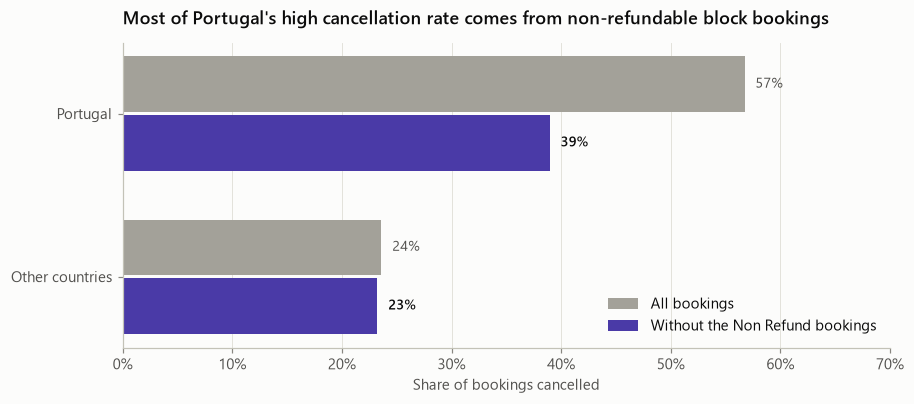

In [11]:
df['country_group'] = np.where(df['country'] == 'PRT', 'Portugal', 'Other countries')
groups = ['Portugal', 'Other countries']
all_rates = df.groupby('country_group')['is_canceled'].mean().reindex(groups)
without_nr = df[~non_refund].groupby('country_group')['is_canceled'].mean().reindex(groups)

fig, ax = plt.subplots(figsize=(9, 3.6))
y = np.arange(len(groups))
h = 0.34
ax.barh(y - h / 2 - 0.01, all_rates, h, color=GREY, label='All bookings')
ax.barh(y + h / 2 + 0.01, without_nr, h, color=MAIN, label='Without the Non Refund bookings')
for yi, (a, b) in enumerate(zip(all_rates, without_nr)):
    ax.text(a + 0.01, yi - h / 2 - 0.01, f'{a:.0%}', va='center', fontsize=9, color=INK2)
    ax.text(b + 0.01, yi + h / 2 + 0.01, f'{b:.0%}', va='center', fontsize=9, fontweight='semibold')
ax.set_yticks(y, groups)
ax.invert_yaxis()
ax.set_xlim(0, 0.7)
ax.xaxis.set_major_formatter(pct)
ax.grid(axis='y', visible=False)
ax.legend(loc='lower right')
ax.set_xlabel('Share of bookings cancelled')
ax.set_title("Most of Portugal's high cancellation rate comes from non-refundable block bookings")
save(fig, '03_portugal_vs_non_refund')

**What we found:** the non-refundable bookings are not ordinary travellers.
- **98% have an identical twin row** and 63% are group bookings, so they are booked in blocks.
- They are made far ahead (median 183 days vs 57).
- 88% are for the City Hotel, and 28% come through a single travel agent (agent no. 1).
- 97% are recorded as coming from Portugal.

**Most likely explanation:** these are rooms reserved in bulk by agencies or tour operators and released later when they couldn't sell them. The "Non Refund" label probably describes the rate plan, not a deposit that a real guest lost. This is a hypothesis, and the next step would be to ask the hotel how these bookings are recorded.

**The Portugal effect mostly disappears:** without these bookings, Portugal's cancellation rate drops from 57% to 39%, while other countries barely move (24% → 23%). Portugal is still higher. Domestic guests may simply book with less commitment, or the guest's country may only be corrected at check-in, so cancelled bookings keep a default of "Portugal". We can't tell these apart with this data, so we leave country out of the prediction model.

**Lesson:** two charts that seemed to show two separate findings ("Non Refund cancels a lot" and "Portugal cancels a lot") were really **one group of bookings seen from two angles**. This is called *confounding*.

### 3.5 Columns that "know the future" (data leakage)

Some columns are filled in **after** the booking is made, for example at check-in. They look like great predictors, but only because they already contain the answer. Using them would be cheating.

In [12]:
checks = {
    'Asked for a parking space': df['required_car_parking_spaces'] > 0,
    'Got a different room type than booked': df['assigned_room_type'] != df['reserved_room_type'],
    'Booking was changed at least once': df['booking_changes'] > 0,
    'All bookings': pd.Series(True, index=df.index),
}
pd.DataFrame({
    'Bookings': {k: f'{m.sum():,}' for k, m in checks.items()},
    'Cancelled': {k: f"{df.loc[m, 'is_canceled'].mean():.1%}" for k, m in checks.items()},
})

,Bookings,Cancelled
Asked for a parking space,"7,409",0.0%
Got a different room type than booked,"14,795",5.4%
Booking was changed at least once,"17,976",15.7%
All bookings,"119,208",37.1%


- **Parking: 0% cancelled out of 7,416 bookings.** That is too perfect to be real. The parking space is most likely recorded when the guest arrives, so only guests who showed up can have one.
- **Different room type: 5% cancelled.** The room is assigned at check-in, so again only arriving guests get one.
- **Booking changes:** a booking that stays alive longer collects more changes. This is partly the same effect.

So we do **not** claim "asking for parking prevents cancellations", and we keep these columns out of the prediction model in Section 7. The reservation status columns (`reservation_status`, `reservation_status_date`) are excluded too, because they *are* the answer.

### 3.6 Does keeping the duplicates change the story?

We kept the duplicate rows in Section 2. A good habit is to check that the main results hold under the other choice too.

In [13]:
dedup = df.drop_duplicates(subset=ORIGINAL_COLUMNS)

def rates(d):
    out = {'All bookings': d['is_canceled'].mean()}
    out.update(d.groupby('hotel')['is_canceled'].mean().to_dict())
    out.update(d.groupby('lead_time_group', observed=True)['is_canceled'].mean().add_prefix('Lead time ').to_dict())
    out.update(d.groupby('deposit_type')['is_canceled'].mean().add_prefix('Deposit: ').to_dict())
    return pd.Series(out)

pd.DataFrame({
    f'With duplicates ({len(df):,} rows)': rates(df),
    f'Without duplicates ({len(dedup):,} rows)': rates(dedup),
}).map(lambda v: f'{v:.0%}')

,"With duplicates (119,208 rows)","Without duplicates (87,228 rows)"
All bookings,37%,28%
City Hotel,42%,30%
Resort Hotel,28%,23%
Lead time 0-7 days,10%,8%
Lead time 8-30,28%,25%
Lead time 31-90,38%,32%
Lead time 91-180,45%,35%
Lead time 181-365,55%,40%
Lead time Over 1 year,68%,41%
Deposit: No Deposit,28%,27%


**The story holds.** Without duplicates, every rate gets lower (overall 37% → 28%), but every pattern stays the same:
- Cancellations still rise with lead time (8% → 41%).
- The City Hotel still cancels more than the Resort Hotel (30% vs 23%).
- Non-refundable bookings still cancel almost always (95%).

So we can be confident about the *direction* of every finding. For the *exact* overall cancellation rate, it is honest to say **"between 28% and 37%, depending on how duplicates are treated"**.

## 4. Seasonality

### 4.1 The month trap

The data runs from **July 2015 to August 2017**. So July and August appear in **three** years of data, and every other month in only **two**. If you add up bookings per month, July and August win just because they were counted more often.

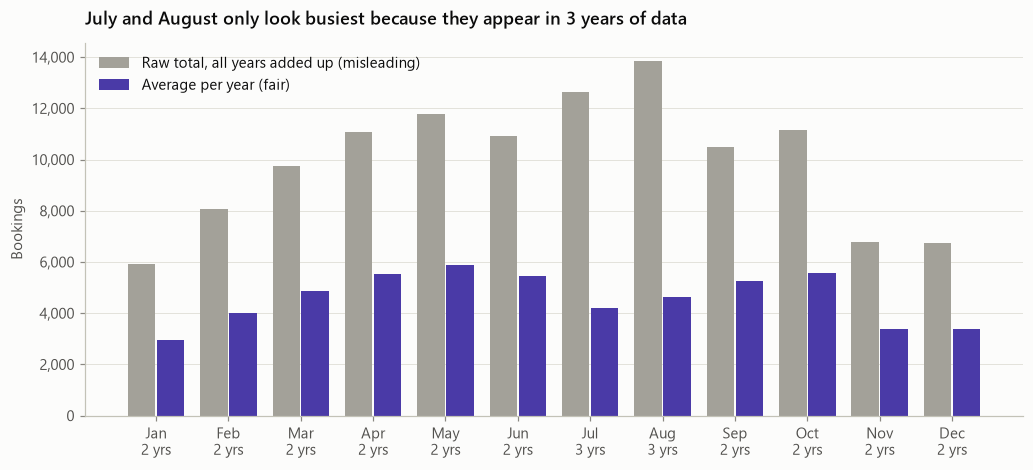

,total,years,per_year
arrival_date_month,,,
January,5921,2,2960
February,8052,2,4026
March,9766,2,4883
April,11078,2,5539
May,11780,2,5890
June,10929,2,5464
July,12644,3,4214
August,13861,3,4620
September,10500,2,5250


In [14]:
m = df.groupby('arrival_date_month').agg(total=('hotel', 'size'),
                                         years=('arrival_date_year', 'nunique')).reindex(MONTHS)
m['per_year'] = m['total'] / m['years']

fig, ax = plt.subplots(figsize=(11, 4.4))
x = np.arange(12)
w = 0.38
ax.bar(x - w / 2 - 0.01, m['total'], w, color=GREY, label='Raw total, all years added up (misleading)')
ax.bar(x + w / 2 + 0.01, m['per_year'], w, color=MAIN, label='Average per year (fair)')
ax.set_xticks(x, [f'{a}\n{y} yrs' for a, y in zip(MONTH_ABBR, m['years'])])
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.grid(axis='x', visible=False)
ax.legend(loc='upper left')
ax.set_ylabel('Bookings')
ax.set_title('July and August only look busiest because they appear in 3 years of data')
save(fig, '04_month_trap')
m.astype(int)

The fairest view is a **single complete year**. 2016 is the only year with all 12 months, so the next charts use 2016 only.

### 4.2 A full year: 2016

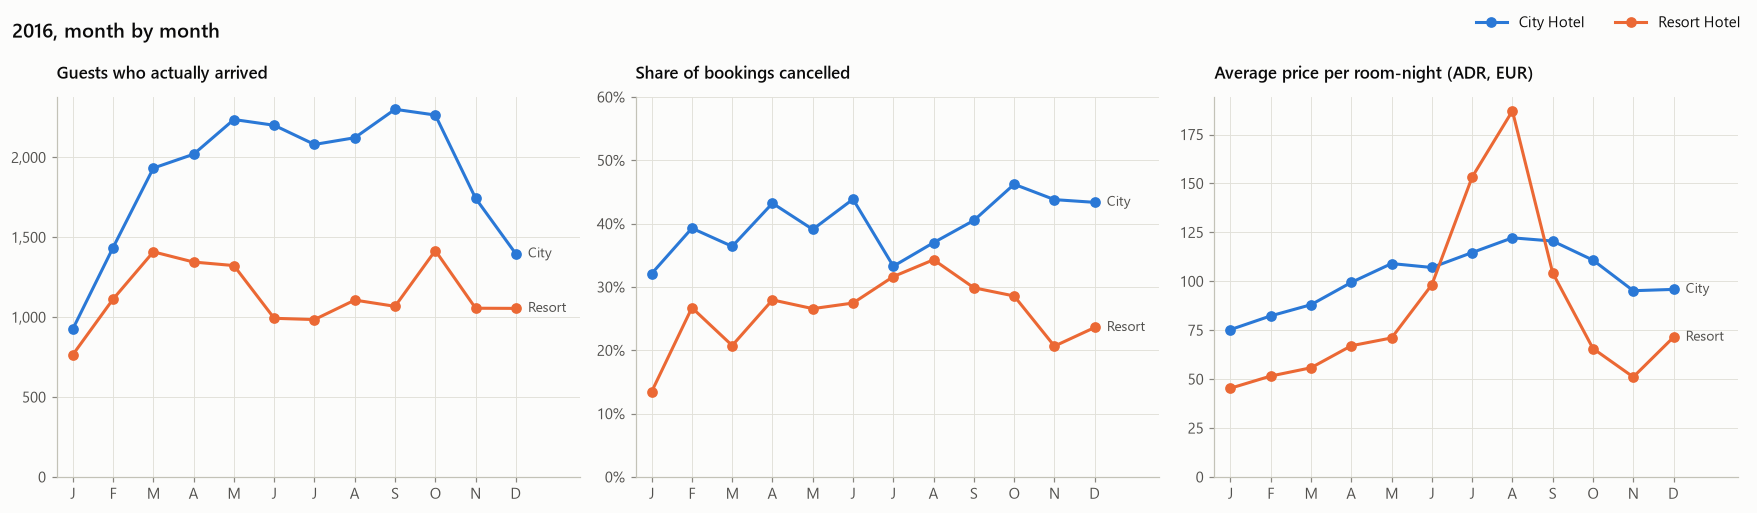

In [15]:
d16 = df[df['arrival_date_year'] == 2016]
arrived16 = d16[d16['is_canceled'] == 0]

panels = [
    ('Guests who actually arrived', arrived16.groupby(['month_num', 'hotel']).size().unstack(), '{:,.0f}'),
    ('Share of bookings cancelled', d16.groupby(['month_num', 'hotel'])['is_canceled'].mean().unstack(), None),
    ('Average price per room-night (ADR, EUR)', arrived16.groupby(['month_num', 'hotel'])['adr'].mean().unstack(), '{:,.0f}'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, (title, table, fmt) in zip(axes, panels):
    for hotel in ['City Hotel', 'Resort Hotel']:
        ax.plot(table.index, table[hotel], marker='o', color=HOTEL_COLORS[hotel], label=hotel)
        ax.text(12.3, table[hotel].iloc[-1], hotel.split()[0], va='center', fontsize=9, color=INK2)
    ax.set_xticks(range(1, 13), [a[0] for a in MONTH_ABBR])
    ax.set_xlim(0.6, 13.6)
    ax.set_title(title, fontsize=11)
    if fmt is None:
        ax.yaxis.set_major_formatter(pct)
        ax.set_ylim(0, 0.6)
    else:
        ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _, f=fmt: f.format(v)))
        ax.set_ylim(bottom=0)
handles, names = axes[0].get_legend_handles_labels()
fig.legend(handles, names, loc='upper right', ncol=2, bbox_to_anchor=(1, 1.02))
fig.suptitle('2016, month by month', x=0.01, ha='left', fontsize=13, fontweight='semibold')
fig.tight_layout()
save(fig, '05_seasonality_2016')

**What 2016 shows**
- **City Hotel:** busy from March to October (about 1,900-2,300 arriving bookings a month). The busiest months are September and October, with a small dip in July and August. Prices still rise in summer (EUR 75 per night in January, EUR 122 in August).
- **Resort Hotel:** arrivals are fairly flat (about 1,000-1,400 a month outside January), but **summer is completely different in value.** The price per night jumps from EUR 45 in January to EUR 187 in August, and summer guests stay longer (5.1-5.6 nights from June to September, vs 2.5 in January). July and August alone bring in 37% of the Resort's 2016 room revenue.
- **Cancellations:** the City Hotel stays high all year (32%-46%), peaking in October. The Resort ranges from 13% in January to 34% in August, so it is most at risk in its most valuable months.

**Lesson:** "busiest" depends on what you count: bookings, guests, nights or money. Always say which one you mean.

## 5. Revenue

`booking_value` = price per night (`adr`) x number of nights. It is only **real revenue if the guest arrives**. A common mistake is to add it up for all bookings, which counts money from cancelled bookings that never came in.

(This is an estimate of room revenue only: no meals, extras or cancellation fees.)

In [16]:
rev = df.pivot_table(index='hotel', columns='is_canceled', values='booking_value', aggfunc='sum')
rev.columns = ['Realised revenue', 'Value of cancelled bookings']
rev.loc['Both hotels'] = rev.sum()
rev['Wrong total (everything added)'] = rev.sum(axis=1)
rev['Share of booked value cancelled'] = rev['Value of cancelled bookings'] / rev['Wrong total (everything added)']

out = rev.copy()
for c in out.columns[:3]:
    out[c] = (rev[c] / 1e6).map('EUR {:,.1f}M'.format)
out['Share of booked value cancelled'] = rev['Share of booked value cancelled'].map('{:.0%}'.format)
out

,Realised revenue,Value of cancelled bookings,Wrong total (everything added),Share of booked value cancelled
hotel,,,,
City Hotel,EUR 14.4M,EUR 10.9M,EUR 25.3M,43%
Resort Hotel,EUR 11.6M,EUR 5.8M,EUR 17.4M,33%
Both hotels,EUR 26.0M,EUR 16.7M,EUR 42.7M,39%


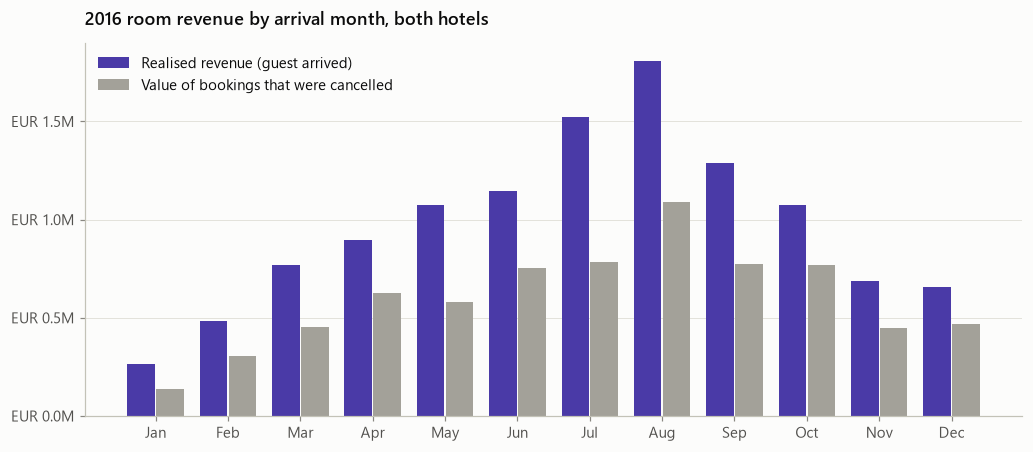

In [17]:
monthly = d16.pivot_table(index='month_num', columns='is_canceled', values='booking_value', aggfunc='sum') / 1e6

fig, ax = plt.subplots(figsize=(11, 4.4))
x = np.arange(12)
w = 0.38
ax.bar(x - w / 2 - 0.01, monthly[0], w, color=MAIN, label='Realised revenue (guest arrived)')
ax.bar(x + w / 2 + 0.01, monthly[1], w, color=GREY, label='Value of bookings that were cancelled')
ax.set_xticks(x, MONTH_ABBR)
ax.yaxis.set_major_locator(MultipleLocator(0.5))
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'EUR {v:,.1f}M'))
ax.grid(axis='x', visible=False)
ax.legend(loc='upper left')
ax.set_title('2016 room revenue by arrival month, both hotels')
save(fig, '06_revenue_2016')

**What this shows:** bookings worth **EUR 42.7M** were made, but only **EUR 26.0M** turned into revenue. Cancelled bookings were worth **EUR 16.7M (39%)**: EUR 10.9M at the City Hotel (43% of its booked value) and EUR 5.8M at the Resort (33%).

The gap is biggest in August, the most valuable month.

**Careful with the word "lost":** some of those cancelled rooms were re-sold to other guests, and some cancellations may have paid a fee. EUR 16.7M is the value of cancelled bookings, not the money actually lost. The real loss is smaller, but this data can't tell us how much.

## 6. Are the differences real? Statistical tests

A test answers: *could this difference just be random luck?* The **p-value** is the chance of seeing a difference this big if there were really no difference. Below 0.05 we usually call it "statistically significant".

**Important:** with 119,000 rows almost *everything* is significant, even tiny differences. So we also report an **effect size**, which says how *big* the difference is. Always look at both.

In [18]:
# Test 1: Do City and Resort guests cancel at different rates?  -> chi-square test (two yes/no-type variables)
table = pd.crosstab(df['hotel'], df['is_canceled'])
chi2, p, dof, expected = stats.chi2_contingency(table)
cramers_v = np.sqrt(chi2 / table.values.sum())          # effect size: 0 = no link, 1 = perfect link
print('1) Hotel vs cancellation')
print(f'   p-value = {p:.1e}   Cramer\'s V = {cramers_v:.2f}\n')

# Test 2: Do cancelled bookings have longer lead times?  -> Mann-Whitney U test (numbers that are not bell-shaped)
cancelled = df.loc[df['is_canceled'] == 1, 'lead_time']
kept = df.loc[df['is_canceled'] == 0, 'lead_time']
u, p = stats.mannwhitneyu(cancelled, kept)
r = 2 * u / (len(cancelled) * len(kept)) - 1             # rank-biserial effect size: -1 to 1, 0 = no difference
print('2) Lead time, cancelled vs not cancelled')
print(f'   median {cancelled.median():.0f} vs {kept.median():.0f} days   p-value = {p:.1e}   effect size r = {r:.2f}\n')

# Test 3: Is the City Hotel more expensive per night?
city = df.loc[(df['hotel'] == 'City Hotel') & (df['is_canceled'] == 0), 'adr']
resort = df.loc[(df['hotel'] == 'Resort Hotel') & (df['is_canceled'] == 0), 'adr']
u, p = stats.mannwhitneyu(city, resort)
r = 2 * u / (len(city) * len(resort)) - 1
print('3) Price per night (arrived guests), City vs Resort')
print(f'   median EUR {city.median():.0f} vs EUR {resort.median():.0f}   p-value = {p:.1e}   effect size r = {r:.2f}')

1) Hotel vs cancellation
   p-value = 0.0e+00   Cramer's V = 0.14

2) Lead time, cancelled vs not cancelled
   median 113 vs 45 days   p-value = 0.0e+00   effect size r = 0.38

3) Price per night (arrived guests), City vs Resort
   median EUR 100 vs EUR 72   p-value = 0.0e+00   effect size r = 0.31


In [19]:
# Experiment: the same test as Test 1, but on a small random sample.
# Change random_state and run again a few times. Watch the p-value jump around.
small = df.sample(200, random_state=1)
chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(small['hotel'], small['is_canceled']))
print(f'Only 200 bookings: p-value = {p:.3f}')
print(small.groupby('hotel')['is_canceled'].mean().map('{:.0%}'.format).to_string())

Only 200 bookings: p-value = 0.125
hotel
City Hotel      35%
Resort Hotel    24%


**How to read these results**
- All three p-values print as `0.0e+00`. That means smaller than the computer can show, so **none of these differences is luck**.
- But the **effect sizes** are what tell you if it matters:
  - **Hotel vs cancellation: Cramer's V = 0.14.** That is a real but *small-to-moderate* link. Knowing the hotel helps only a little to predict a cancellation.
  - **Lead time: r = 0.38, a moderate effect.** Cancelled bookings were made a median 113 days ahead, versus 45 days for kept bookings.
  - **Price: r = 0.31, a moderate effect.** The City Hotel's median is EUR 100 per night, versus EUR 72 at the Resort.
- **The 200-booking experiment:** the sample still shows the City Hotel cancelling more (35% vs 24%), but the p-value is 0.125, which is *not significant*. With few rows, even a real difference can't be proven. With 119,000 rows, even tiny differences become "significant". **Sample size changes the p-value, not the truth.**

## 7. Predicting cancellations

**Goal:** when a booking comes in, estimate how likely it is to be cancelled. Hotels can use this to overbook carefully or to contact risky guests.

**Rules we follow**
1. **Only use information known when the booking is made.** We leave out reservation status, parking, assigned room, booking changes (see 3.5) and the guest's country (see 3.4: it may be fixed only at check-in).
2. **Test on the future.** We train on arrivals in 2015-2016 and test on 2017 arrivals, like using the model for real. This also stops identical twin rows landing on both sides of the split.
3. **Compare with a simple baseline.** If the model can't beat "guess that nobody cancels", it is useless.

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

NUMERIC = ['lead_time', 'arrival_date_week_number', 'stays_in_weekend_nights', 'stays_in_week_nights',
           'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations',
           'previous_bookings_not_canceled', 'days_in_waiting_list', 'adr', 'total_of_special_requests',
           'has_agent', 'has_company']
CATEGORICAL = ['hotel', 'arrival_date_month', 'meal', 'market_segment', 'distribution_channel',
               'reserved_room_type', 'deposit_type', 'customer_type']
FEATURES = NUMERIC + CATEGORICAL

train = df[df['arrival_date'] < '2017-01-01']
test = df[df['arrival_date'] >= '2017-01-01']
print(f'Train: {len(train):,} bookings (Jul 2015 - Dec 2016), {train.is_canceled.mean():.0%} cancelled')
print(f'Test:  {len(test):,} bookings (Jan - Aug 2017), {test.is_canceled.mean():.0%} cancelled')


def make_model(estimator, numeric=NUMERIC, categorical=CATEGORICAL):
    """Pipeline = prepare the columns, then fit the model. Same steps for train and test, no mix-ups."""
    prep = ColumnTransformer([
        ('num', StandardScaler(), numeric),                                     # put numbers on the same scale
        ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=50,
                              sparse_output=False), categorical),               # text -> 0/1 columns
    ])
    return Pipeline([('prep', prep), ('model', estimator)])


models = {
    'Logistic regression': make_model(LogisticRegression(max_iter=3000)),
    'Gradient boosting': make_model(HistGradientBoostingClassifier(random_state=42)),
}
scores = {}
for name, model in models.items():
    model.fit(train[FEATURES], train['is_canceled'])
    scores[name] = model.predict_proba(test[FEATURES])[:, 1]
    print(f'{name:20s} AUC on 2017 = {roc_auc_score(test.is_canceled, scores[name]):.3f}')

Train: 78,589 bookings (Jul 2015 - Dec 2016), 36% cancelled
Test:  40,619 bookings (Jan - Aug 2017), 39% cancelled


Logistic regression  AUC on 2017 = 0.807


Gradient boosting    AUC on 2017 = 0.825


**AUC** (area under the curve) measures how well the model ranks bookings from "will cancel" to "won't cancel": 0.5 = coin flip, 1.0 = perfect.

**What if we had cheated?** Let's add the leaky columns back and see what happens:

In [21]:
leaky_numeric = NUMERIC + ['required_car_parking_spaces', 'booking_changes']
leaky_categorical = CATEGORICAL + ['assigned_room_type', 'country']
cheat = make_model(HistGradientBoostingClassifier(random_state=42), leaky_numeric, leaky_categorical)
cheat.fit(train[leaky_numeric + leaky_categorical], train['is_canceled'])
cheat_auc = roc_auc_score(test.is_canceled, cheat.predict_proba(test[leaky_numeric + leaky_categorical])[:, 1])
print(f'With leaky columns: AUC = {cheat_auc:.3f}  <- looks better, but uses information we would not have yet')

With leaky columns: AUC = 0.874  <- looks better, but uses information we would not have yet


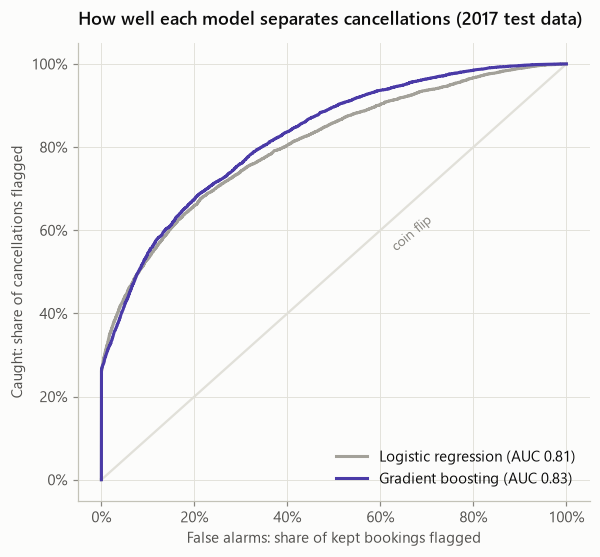

In [22]:
fig, ax = plt.subplots(figsize=(6, 5.4))
ax.plot([0, 1], [0, 1], color=GRID, lw=1.5)
ax.text(0.62, 0.55, 'coin flip', color=MUTED, fontsize=9, rotation=40)
for name, color in [('Logistic regression', GREY), ('Gradient boosting', MAIN)]:
    fpr, tpr, _ = roc_curve(test.is_canceled, scores[name])
    auc = roc_auc_score(test.is_canceled, scores[name])
    ax.plot(fpr, tpr, color=color, label=f'{name} (AUC {auc:.2f})')
ax.set_xlabel('False alarms: share of kept bookings flagged')
ax.set_ylabel('Caught: share of cancellations flagged')
ax.xaxis.set_major_formatter(pct)
ax.yaxis.set_major_formatter(pct)
ax.legend(loc='lower right')
ax.set_title('How well each model separates cancellations (2017 test data)')
save(fig, '07_model_roc')

In [23]:
# What does that mean in practice? Flag every booking with a predicted risk of 50% or more.
best = scores['Gradient boosting']
flag = best >= 0.5
y = test['is_canceled']
print(f'Baseline "nobody cancels" accuracy:  {1 - y.mean():.1%}')
print(f'Model accuracy:                       {accuracy_score(y, flag):.1%}')
print(f'Of the bookings the model flags, {precision_score(y, flag):.0%} really are cancelled (precision)')
print(f'Of all real cancellations, the model catches {recall_score(y, flag):.0%} (recall)')

# Risk bands: how often do bookings in each risk band actually cancel?
bands = pd.cut(best, [0, 0.2, 0.4, 0.6, 0.8, 1], labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%'], include_lowest=True)
check = pd.DataFrame({'band': bands, 'cancelled': y.values}).groupby('band', observed=True)['cancelled'].agg(bookings='size', actually_cancelled='mean')
check['actually_cancelled'] = check['actually_cancelled'].map('{:.0%}'.format)
check.rename_axis('Predicted risk')

Baseline "nobody cancels" accuracy:  61.3%
Model accuracy:                       76.2%
Of the bookings the model flags, 78% really are cancelled (precision)
Of all real cancellations, the model catches 54% (recall)


,bookings,actually_cancelled
Predicted risk,,
0-20%,18366,15%
20-40%,10314,38%
40-60%,2104,56%
60-80%,5364,65%
80-100%,4471,98%


**Which information matters most to the model?** *Permutation importance*: shuffle one column at a time and measure how much worse the model gets. A big drop means the model relies on that column.

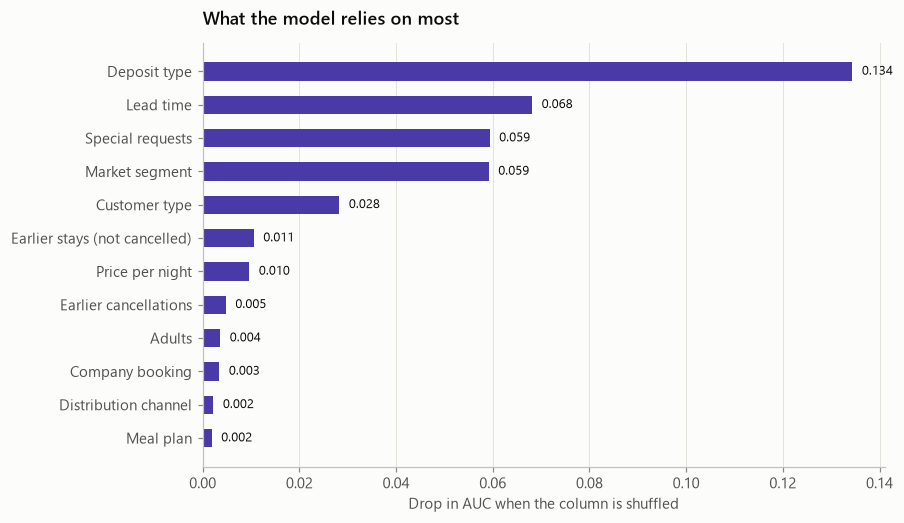

In [24]:
sample = test.sample(8000, random_state=0)
imp = permutation_importance(models['Gradient boosting'], sample[FEATURES], sample['is_canceled'],
                             scoring='roc_auc', n_repeats=5, random_state=0)
NICE_NAMES = {
    'deposit_type': 'Deposit type', 'lead_time': 'Lead time', 'total_of_special_requests': 'Special requests',
    'market_segment': 'Market segment', 'customer_type': 'Customer type', 'adr': 'Price per night',
    'previous_bookings_not_canceled': 'Earlier stays (not cancelled)', 'previous_cancellations': 'Earlier cancellations',
    'adults': 'Adults', 'has_company': 'Company booking', 'has_agent': 'Booked via agent',
    'distribution_channel': 'Distribution channel', 'meal': 'Meal plan', 'hotel': 'Hotel',
    'arrival_date_month': 'Arrival month', 'arrival_date_week_number': 'Arrival week',
    'reserved_room_type': 'Room type', 'stays_in_week_nights': 'Week nights', 'stays_in_weekend_nights': 'Weekend nights',
    'children': 'Children', 'babies': 'Babies', 'is_repeated_guest': 'Repeat guest', 'days_in_waiting_list': 'Days on waiting list',
}
importance = pd.Series(imp.importances_mean, index=FEATURES).sort_values(ascending=False).head(12)
importance.index = importance.index.map(NICE_NAMES)

fig, ax = plt.subplots(figsize=(8, 5))
y = np.arange(len(importance))
ax.barh(y, importance, color=MAIN, height=0.55)
ax.set_yticks(y, importance.index)
ax.invert_yaxis()
for yi, v in enumerate(importance):
    ax.text(v + 0.002, yi, f'{v:.3f}', va='center', fontsize=8.5)
ax.grid(axis='y', visible=False)
ax.set_xlabel('Drop in AUC when the column is shuffled')
ax.set_title('What the model relies on most')
save(fig, '08_feature_importance')

**Results**
- **Gradient boosting reaches AUC 0.83 on 2017 data, and logistic regression 0.81.** The simpler model is almost as good and much easier to explain, which is useful to know.
- **Accuracy is 76%, versus 61% for the "nobody cancels" guess.** When the model flags a booking (risk ≥ 50%), it is right 78% of the time, but it only catches 54% of all cancellations. Lowering the threshold catches more cancellations but raises more false alarms. That is a business choice, not a technical one.
- **Risk bands work:** bookings rated 80-100% risky were cancelled 98% of the time, and those rated 0-20% only 15%.
- **What it relies on:** deposit type (mostly the block bookings), lead time, special requests, market segment and customer type, the same drivers we found in Section 3. When the model and the charts agree, both are more believable.
- **The cheat test:** adding the leaky columns raises AUC to 0.87. It looks better, but the model would fail in real life because that information doesn't exist yet when the booking is made.

## 8. Conclusions and recommendations

**What we learned**
1. **37% of bookings (39% of booked room value, EUR 16.7M) are cancelled.** The City Hotel is hit hardest.
2. **The longer the lead time, the higher the risk:** from 10% to 68%.
3. **A third of all cancellations come from about 14,600 "non-refundable" block bookings** that behave nothing like normal guests. They also explain most of Portugal's high rate.
4. **Commitment signals predict who shows up:** special requests, repeat stays and booking directly.
5. **Summer matters most for the Resort Hotel's revenue**, because of price and length of stay, not the number of guests.
6. **Cancellations are predictable (AUC 0.83)** using only what is known at booking time.

**Recommendations for the hotels**
1. **Treat block bookings separately.** Report cancellation rates with and without them. Agree release deadlines with the agencies that hold large blocks (for example agent no. 1), so unsold rooms come back early enough to resell.
2. **Use lead time in the cancellation policy.** For bookings made 6+ months ahead, ask for a small deposit or offer a discount for a non-refundable rate. Send a reconfirmation message about 30 days before arrival.
3. **Grow direct and repeat bookings.** Offer a best-price guarantee on the hotel's own website and a simple loyalty perk. Both groups cancel far less than online-agent bookings.
4. **Encourage pre-arrival engagement.** Asking guests for their preferences (room, arrival time, extras) turns them into the "special requests" group that cancels less. Test this with an experiment before rolling it out, because the link might not be cause and effect.
5. **Use the risk score for careful overbooking**, especially on summer dates at the Resort, where an empty room is most expensive. Bookings in the 80-100% band can be counted as very likely to be released.

## Limitations

- **Two hotels in Portugal, 2015-2017**, before COVID-19. Travel habits have changed since, so check before applying these results elsewhere.
- **No booking ID.** We can't be sure whether identical rows are separate rooms or data errors, so the overall rate is 28%-37% depending on that choice.
- **Revenue is an estimate** (price × nights). It ignores cancellation fees, re-sold rooms, meals and extras.
- **Some columns may be recorded at check-in** (parking, assigned room and maybe special requests). We removed the clear cases from the model, but can't be 100% sure about the rest.
- **Correlation is not causation.** Guests who make special requests cancel less, but that does not prove that asking for requests *causes* guests to stay. Only an experiment can show that.